# **Análisis exploratorio de datos**

### *Default clients*

0. Importación de librerias 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Carga de datos 

In [2]:
ruta_archivo = "C:/Users/norba/OneDrive/NUESTRO HOGAR/1. ANGEL SANTIAGO/Proyecto Banco/default of credit card clients.csv"
df = pd.read_csv(ruta_archivo, sep=";", skiprows=1)

print("\n--- Estructura inicial del Dataset ---")
print(df.info())
print("\n", df.describe())



--- Estructura inicial del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2            

2. Limpieza e imputación 

In [3]:
cols_numericas = df.select_dtypes(include=[np.number]).columns
cols_texto = df.select_dtypes(include=['object']).columns

# Imputación: mediana para numéricas, moda para categóricas
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

if not cols_texto.empty:
    for col in cols_texto:
        df[col] = df[col].fillna(df[col].mode()[0])

# Renombrar la variable objetivo
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

# Convertir variables que conceptualmente son categóricas al tipo 'category'
cols_categoricas = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", 
                    "PAY_4", "PAY_5", "PAY_6", "DEFAULT"]

for col in cols_categoricas:
    df[col] = df[col].astype('category')


3. ESTADÍSTICAS DESCRIPTIVAS POST-LIMPIEZA

In [4]:
print("\n--- Resumen de Datos Limpios ---")
print(df.describe(include='all'))


--- Resumen de Datos Limpios ---
                  ID       LIMIT_BAL      SEX  EDUCATION  MARRIAGE  \
count   30000.000000    30000.000000  30000.0    30000.0   30000.0   
unique           NaN             NaN      2.0        7.0       4.0   
top              NaN             NaN      2.0        2.0       2.0   
freq             NaN             NaN  18112.0    14030.0   15964.0   
mean    15000.500000   167484.322667      NaN        NaN       NaN   
std      8660.398374   129747.661567      NaN        NaN       NaN   
min         1.000000    10000.000000      NaN        NaN       NaN   
25%      7500.750000    50000.000000      NaN        NaN       NaN   
50%     15000.500000   140000.000000      NaN        NaN       NaN   
75%     22500.250000   240000.000000      NaN        NaN       NaN   
max     30000.000000  1000000.000000      NaN        NaN       NaN   

                 AGE    PAY_0    PAY_2    PAY_3    PAY_4  ...      BILL_AMT4  \
count   30000.000000  30000.0  30000.0  30000

4. VISUALIZACIÓN DE DATOS

C:\Users\norba\AppData\Local\Temp\ipykernel_6140\1888752937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DEFAULT', palette='Set2', edgecolor='black')


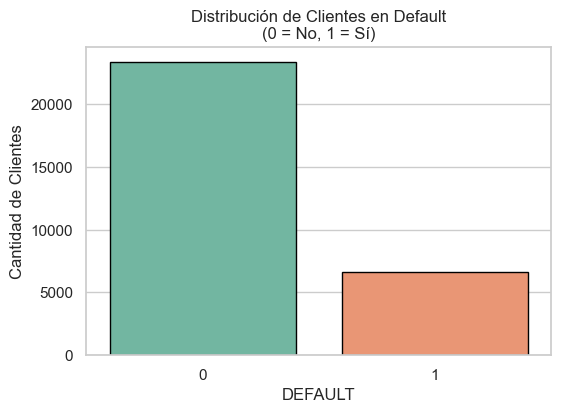

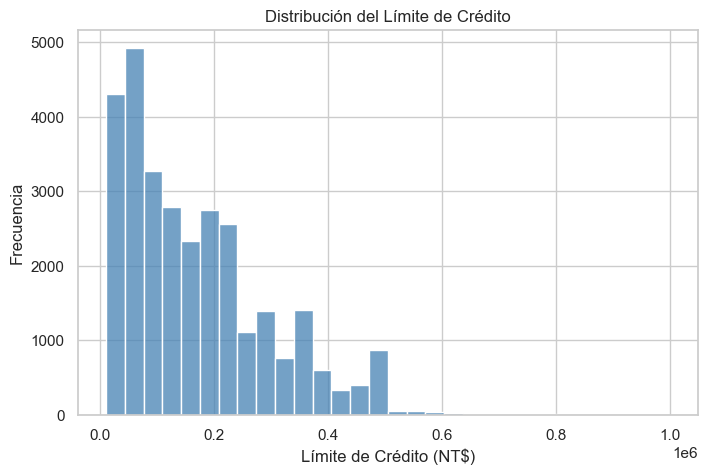

C:\Users\norba\AppData\Local\Temp\ipykernel_6140\1888752937.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='DEFAULT', y='LIMIT_BAL', palette='Set2')


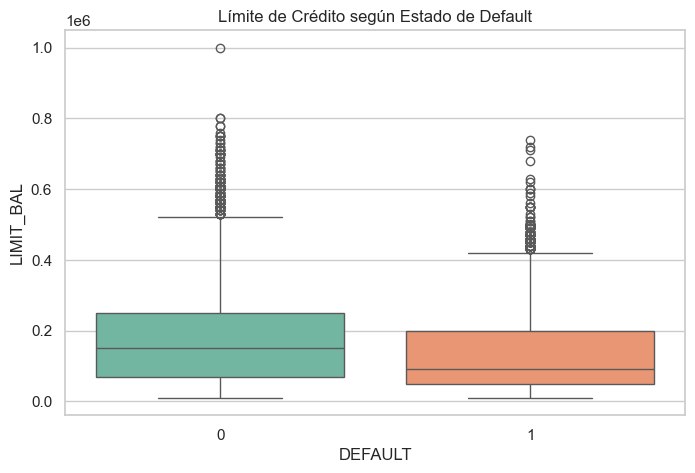

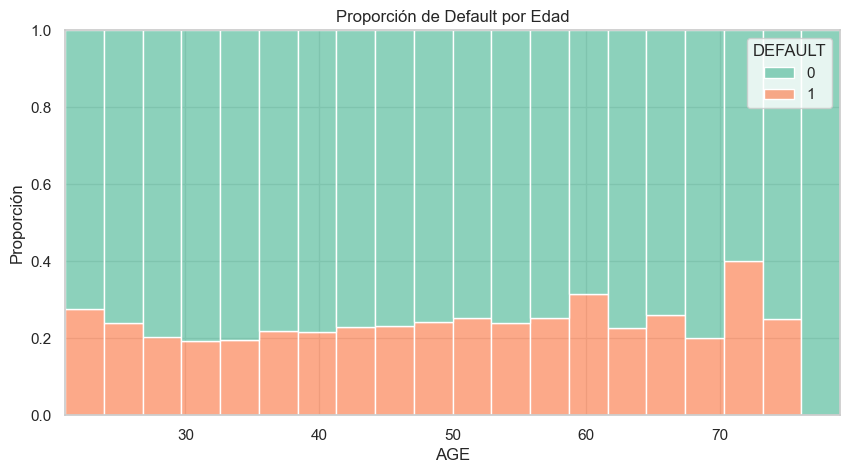

In [7]:
sns.set_theme(style="whitegrid")

# a) Distribución de la variable objetivo (Default)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DEFAULT', palette='Set2', edgecolor='black')
plt.title('Distribución de Clientes en Default\n(0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.show()

# b) Histograma del límite de crédito (LIMIT_BAL)
plt.figure(figsize=(8, 5))
sns.histplot(df['LIMIT_BAL'], bins=30, color='steelblue', kde=False)
plt.title('Distribución del Límite de Crédito')
plt.xlabel('Límite de Crédito (NT$)')
plt.ylabel('Frecuencia')
plt.show()

# c) Boxplot de Límite de crédito vs Default
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='DEFAULT', y='LIMIT_BAL', palette='Set2')
plt.title('Límite de Crédito según Estado de Default')
plt.show()

# d) Relación entre Edad e Impagos (Proporción)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='AGE', hue='DEFAULT', multiple='fill', bins=20, palette='Set2')
plt.title('Proporción de Default por Edad')
plt.ylabel('Proporción')
plt.show()

5. PRUEBAS DE NORMALIDAD Y CORRELACIÓN 


--- Evaluación de Normalidad (Asimetría y Curtosis) ---
Variable: LIMIT_BAL - ¿Aceptable? Sí (Asimetría: 0.99, Curtosis: 0.54)
Variable: AGE - ¿Aceptable? Sí (Asimetría: 0.73, Curtosis: 0.04)
Variable: BILL_AMT1 - ¿Aceptable? No (Asimetría: 2.66, Curtosis: 9.81)
Variable: BILL_AMT2 - ¿Aceptable? No (Asimetría: 2.71, Curtosis: 10.30)
Variable: BILL_AMT3 - ¿Aceptable? No (Asimetría: 3.09, Curtosis: 19.78)
Variable: BILL_AMT4 - ¿Aceptable? No (Asimetría: 2.82, Curtosis: 11.31)
Variable: BILL_AMT5 - ¿Aceptable? No (Asimetría: 2.88, Curtosis: 12.31)
Variable: BILL_AMT6 - ¿Aceptable? No (Asimetría: 2.85, Curtosis: 12.27)
Variable: PAY_AMT1 - ¿Aceptable? No (Asimetría: 14.67, Curtosis: 415.25)
Variable: PAY_AMT2 - ¿Aceptable? No (Asimetría: 30.45, Curtosis: 1641.63)
Variable: PAY_AMT3 - ¿Aceptable? No (Asimetría: 17.22, Curtosis: 564.31)
Variable: PAY_AMT4 - ¿Aceptable? No (Asimetría: 12.90, Curtosis: 277.33)
Variable: PAY_AMT5 - ¿Aceptable? No (Asimetría: 11.13, Curtosis: 180.06)
Variable: 

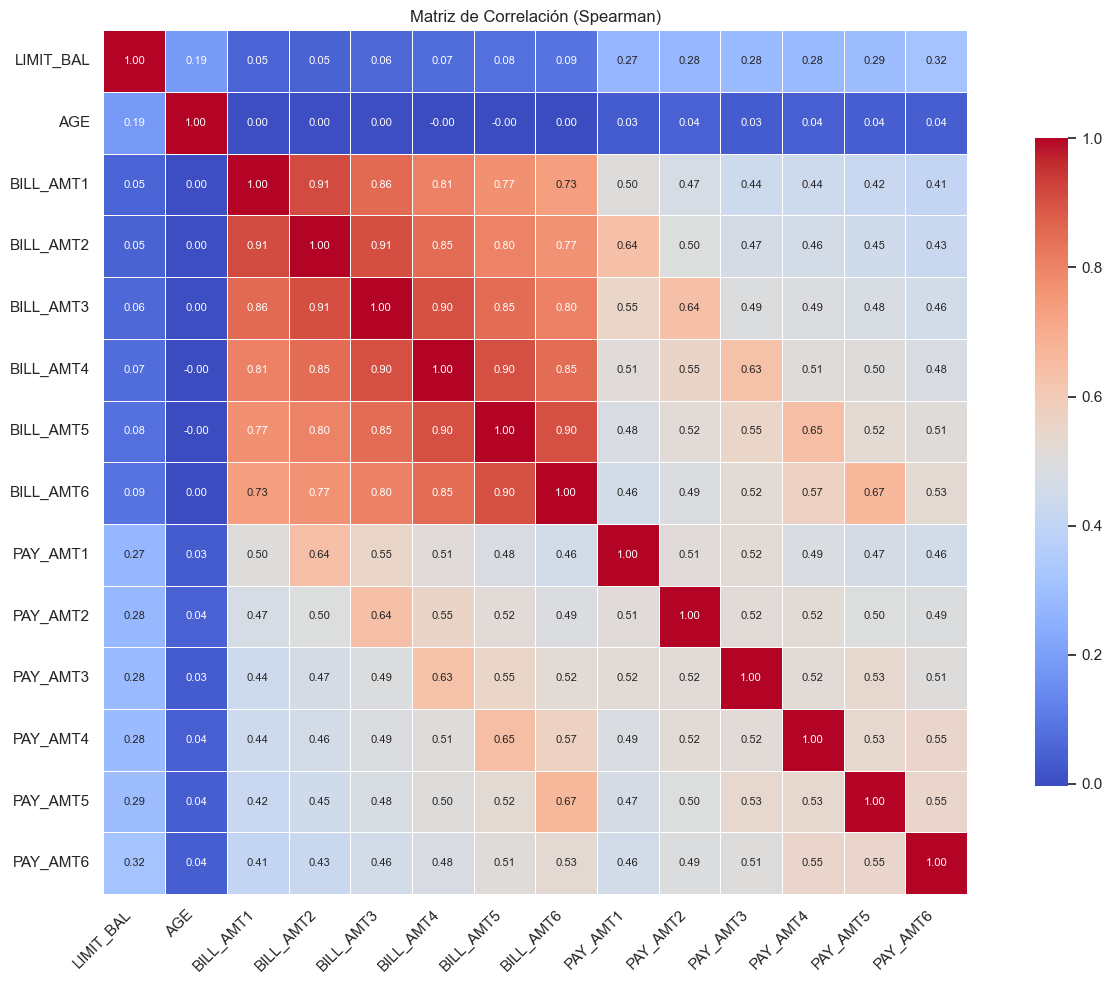

In [8]:
df_numerico = df.select_dtypes(include=[np.number]).drop(columns=['ID'], errors='ignore')

print("\n--- Evaluación de Normalidad (Asimetría y Curtosis) ---")
# Una asimetría entre -2 y 2, y una curtosis entre -2 y 2 suelen ser aceptables 
# para asumir cierta normalidad en muestras grandes.
for col in df_numerico.columns:
    asimetria = df_numerico[col].skew()
    curtosis = df_numerico[col].kurtosis()
    
    es_aceptable = (abs(asimetria) < 2) and (abs(curtosis) < 2)
    print(f"Variable: {col} - ¿Aceptable? {'Sí' if es_aceptable else 'No'} (Asimetría: {asimetria:.2f}, Curtosis: {curtosis:.2f})")

print("\n--- Generando Matriz de Correlación ---")
# Correlación de Spearman calculada directamente con Pandas
matriz_cor = df_numerico.corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_cor, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={"shrink": .75},
            annot_kws={"size": 8})
plt.title('Matriz de Correlación (Spearman)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Conclusiones

1. Desbalance de clases: La gran mayoría de clientes cumple con sus pagos, por lo que cualquier modelo predictivo exigirá técnicas de balanceo.

2. Riesgo por cupo: A menor límite de crédito otorgado, mayor es la tasa de impago.

3. Distribución no normal: Las variables financieras presentan valores extremos, obligando a usar métodos no paramétricos como la correlación de Spearman.

4. Multicolinealidad: Los montos de facturación mensual son casi idénticos entre sí, requiriendo reducción de dimensionalidad para evitar redundancias.

5. Predictor principal: El estado del pago del último mes es el indicador más fuerte y definitivo para predecir el riesgo de default.

### *German*

In [5]:
# Carga de datos German
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
df_german = pd.read_csv(german_data_path, sep=' ', header=None)

german_numeric_path = "../data/german_credit/statlog+german+credit+data/german.data-numeric"
df_german_numeric = pd.read_csv(german_numeric_path, sep=r'\s+', header=None)

print("Dataset German original:")
print(df_german.head())
print("\nDataset German numérico:")
print(df_german_numeric.head())

Dataset German original:
    0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0  A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1  A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2  A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3  A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4  A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   

     14 15    16 17    18    19 20  
0  A152  2  A173  1  A192  A201  1  
1  A152  1  A173  1  A191  A201  2  
2  A152  1  A172  2  A191  A201  1  
3  A153  1  A173  2  A191  A201  1  
4  A153  2  A173  2  A191  A201  2  

[5 rows x 21 columns]

Dataset German numérico:
   0   1   2   3   4   5   6   7   8   9   ...  15  16  17  18  19  20  21  \
0   1   6   4  12   5   5   3   4   1  67  ...   0   0   1   0   0   1   0   
1   2  48   2  60   1   3   2   2   1  22  ...   0   0   1   0   0   1   0   
2   4  12   4